In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.5/fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold0_05["fold"] = [0 for i in range(len(fold0_05))]
fold0_05["target"] = [-0.5 for i in range(len(fold0_05))]

In [3]:
fold1_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.5/fold1_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold1_05["fold"] = [1 for i in range(len(fold1_05))]
fold1_05["target"] = [-0.5 for i in range(len(fold1_05))]

In [4]:
fold2_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.5/fold2_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold2_05["fold"] = [2 for i in range(len(fold2_05))]
fold2_05["target"] = [-0.5 for i in range(len(fold2_05))]

In [5]:
df = pd.concat([fold0_05, fold1_05, fold2_05], ignore_index=True)

In [6]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [7]:
alpha_fold0 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/boundary_generation/fold0_alphagenome_results.tsv", sep="\t")

alpha_fold0["fold"] = [0 for i in range(len(alpha_fold0))]
alpha_fold0["target"] = [-0.5 for i in range(len(alpha_fold0))]

In [8]:
alpha_fold1 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/boundary_generation/fold1_alphagenome_results.tsv", sep="\t")

alpha_fold1["fold"] = [1 for i in range(len(alpha_fold1))]
alpha_fold1["target"] = [-0.5 for i in range(len(alpha_fold1))]

In [9]:
alpha_fold2 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/boundary_generation/fold2_alphagenome_results.tsv", sep="\t")

alpha_fold2["fold"] = [2 for i in range(len(alpha_fold2))]
alpha_fold2["target"] = [-0.5 for i in range(len(alpha_fold2))]

In [10]:
alpha_df = pd.concat([alpha_fold0, alpha_fold1, alpha_fold2], ignore_index=True)

In [11]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

Pearson R = 0.8776, p-value = 1.3050e-53


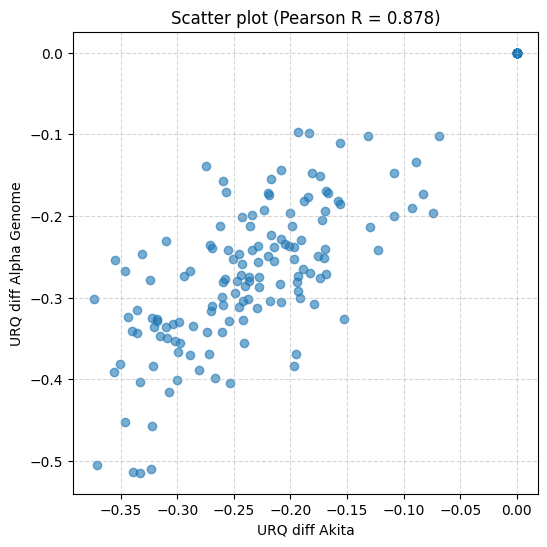

In [13]:
# Assuming df and alpha_df have the same row order
x = df["URQ_diff"].values
y = alpha_df["alpha_urq_diff"].values

# Calculate Pearson correlation
pearson_r, p_value = pearsonr(x, y)
print(f"Pearson R = {pearson_r:.4f}, p-value = {p_value:.4e}")

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("URQ diff Akita")
plt.ylabel("URQ diff Alpha Genome")
plt.title(f"Scatter plot (Pearson R = {pearson_r:.3f})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()